<a href="https://colab.research.google.com/github/Bintangnazwar/-1023---Drought---Jawaban-/blob/main/PRAKTIKUM_MODUL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library dan Load Data (5%)

1. Import library

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

2. Load dataset

In [18]:
# Load dataset
url = "MODULE 1_ASSIGNMENT.csv"

df = pd.read_csv(url)

# Menampilkan 5 data pertama
df.head(100)

,NIM,Nama,IPK,Kehadiran_Persen,Tugas_Persen,Status
0,2022IF001,Irwan Mahardika,3.29,88.0,90.0,Lulus
1,2022IF002,NaN,2.71,56.0,30.0,Tidak Lulus
2,2022IF003,Qisya Wardani,3.59,94.0,70.0,Lulus
3,2022IF004,Cahya Pasaribu,2.32,50.0,30.0,Tidak Lulus
4,2022IF005,Hadi Maulana,3.22,75.0,70.0,Lulus
...,...,...,...,...,...,...
95,2022IF096,Wahyu Putri,2.60,88.0,NaN,Lulus
96,2022IF097,Bagus Fitria,3.23,81.0,80.0,Lulus
97,2022IF098,Yusuf Usman,1.90,50.0,50.0,Tidak Lulus
98,2022IF099,Qori Pratama,3.25,81.0,90.0,Lulus


2. Exploratory Data Analysis (5%)

a. Menampilkan 5 data pertama dan 5 data terakhir

In [4]:
# Menampilkan 5 data pertama
print("5 Data Pertama:")
display(df.head())

# Menampilkan 5 data terakhir
print("\n5 Data Terakhir:")
display(df.tail())

5 Data Pertama:


,NIM,Nama,IPK,Kehadiran_Persen,Tugas_Persen,Status
0,2022IF001,Irwan Mahardika,3.29,88.0,90.0,Lulus
1,2022IF002,NaN,2.71,56.0,30.0,Tidak Lulus
2,2022IF003,Qisya Wardani,3.59,94.0,70.0,Lulus
3,2022IF004,Cahya Pasaribu,2.32,50.0,30.0,Tidak Lulus
4,2022IF005,Hadi Maulana,3.22,75.0,70.0,Lulus



5 Data Terakhir:


,NIM,Nama,IPK,Kehadiran_Persen,Tugas_Persen,Status
245,2022IF246,Nama246,3.04,91.0,NaN,Lulus
246,2022IF247,Nama247,3.50,76.0,62.0,Lulus
247,2022IF248,Nama248,3.17,82.0,57.0,Tidak Lulus
248,2022IF249,Nama249,3.21,94.0,73.0,Lulus
249,2022IF250,Nama250,3.78,86.0,66.0,Lulus


b. Statistical Summary

In [5]:
# Mengambil kolom numerik
numeric_columns = df.select_dtypes(include=np.number).columns

# Membuat tabel statistik
statistical_summary = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Standard Deviation': df[numeric_columns].std(),
    'Minimum': df[numeric_columns].min(),
    'Q1 (25%)': df[numeric_columns].quantile(0.25),
    'Q2 (50%)': df[numeric_columns].quantile(0.50),
    'Q3 (75%)': df[numeric_columns].quantile(0.75),
    'Maximum': df[numeric_columns].max()
})

# Menampilkan hasil
display(statistical_summary)

,Mean,Median,Standard Deviation,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum
IPK,2.918903,3.04,0.526897,1.44,2.68,3.04,3.26,4.0
Kehadiran_Persen,79.032653,81.00,15.863886,31.00,75.00,81.00,91.00,100.0
Tugas_Persen,70.225532,71.00,21.867027,0.00,63.00,71.00,80.00,100.0


c. Visualisasi distribusi label

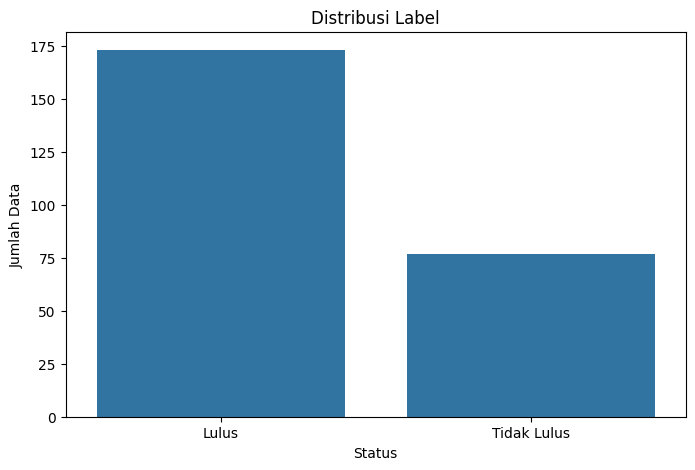

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Status')

plt.title('Distribusi Label')
plt.xlabel('Status')
plt.ylabel('Jumlah Data')

plt.show()

3. Data Preprocessing (5%)

a IPK dan Kehadiran_Persen → Mean

In [8]:
# Mengisi nilai kosong pada kolom IPK dengan nilai rata-rata
df['IPK'] = df['IPK'].fillna(df['IPK'].mean())

# Mengisi nilai kosong pada kolom Kehadiran_Persen dengan nilai rata-rata
df['Kehadiran_Persen'] = df['Kehadiran_Persen'].fillna(
    df['Kehadiran_Persen'].mean()
)

b Tugas_Persen → Median

In [9]:
# Mengisi nilai kosong pada kolom Tugas_Persen dengan nilai median
df['Tugas_Persen'] = df['Tugas_Persen'].fillna(
    df['Tugas_Persen'].median()
)

c Nama → Nama_Tidak_Diketahui

In [10]:
# 3.c Mengisi nilai kosong Nama dengan Nama_Tidak_Diketahui
df['Nama'] = df['Nama'].fillna('Nama_Tidak_Diketahui')

# Menampilkan hasil setelah preprocessing
print("Jumlah missing value setelah preprocessing:")
print(df[['Nama', 'IPK', 'Kehadiran_Persen', 'Tugas_Persen']].isnull().sum())

Jumlah missing value setelah preprocessing:
Nama                0
IPK                 0
Kehadiran_Persen    0
Tugas_Persen        0
dtype: int64


4. Initialize Input (5%)


In [11]:
# Memisahkan fitur (X) dan target (y)

X = df[['IPK', 'Kehadiran_Persen', 'Tugas_Persen']]
y = df['Status']

# Menampilkan hasil
print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Fitur (X):
    IPK  Kehadiran_Persen  Tugas_Persen
0  3.29              88.0          90.0
1  2.71              56.0          30.0
2  3.59              94.0          70.0
3  2.32              50.0          30.0
4  3.22              75.0          70.0

Target (y):
0          Lulus
1    Tidak Lulus
2          Lulus
3    Tidak Lulus
4          Lulus
Name: Status, dtype: object


5. Splitting Data with 80:20 Proportion (5%)

In [12]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% data training dan 20% data testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Menampilkan jumlah data
print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 200
Jumlah data testing : 50


6. Build Naive Bayes Model (10%)

In [13]:
from sklearn.naive_bayes import GaussianNB

# Membuat model Naive Bayes
model = GaussianNB()

# Melatih model menggunakan data training
model.fit(X_train, y_train)

print("Model Naive Bayes berhasil dibuat dan dilatih.")

Model Naive Bayes berhasil dibuat dan dilatih.


7. Evaluate the Model with the Following Conditions: (5%)

a. Display Classification Report

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Menampilkan classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Menampilkan accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Classification Report:
              precision    recall  f1-score   support

       Lulus       0.89      1.00      0.94        33
 Tidak Lulus       1.00      0.76      0.87        17

    accuracy                           0.92        50
   macro avg       0.95      0.88      0.90        50
weighted avg       0.93      0.92      0.92        50

Accuracy: 0.92
Accuracy (%): 92.0


b. Minimum Accuracy 85%

In [15]:
if accuracy >= 0.85:
    print("Model memenuhi syarat accuracy minimum 85%.")
else:
    print("Model belum memenuhi syarat accuracy minimum 85%.")

Model memenuhi syarat accuracy minimum 85%.


8. Test with New Data: (5%)


In [16]:
import pandas as pd

# Membuat data baru
data_baru = pd.DataFrame({
    'IPK': [3.2, 2.1, 3.8],
    'Kehadiran_Persen': [85, 60, 95],
    'Tugas_Persen': [20, 50, 90]
})

# Melakukan prediksi
hasil_prediksi = model.predict(data_baru)

# Menampilkan data dan hasil prediksi
data_baru['Prediksi'] = hasil_prediksi

print(data_baru)

   IPK  Kehadiran_Persen  Tugas_Persen     Prediksi
0  3.2                85            20  Tidak Lulus
1  2.1                60            50  Tidak Lulus
2  3.8                95            90        Lulus


In [17]:
# Keterangan label
label = {
    0: 'Tidak Lulus',
    1: 'Lulus'
}

data_baru['Keterangan'] = data_baru['Prediksi'].map(label)

print(data_baru)

   IPK  Kehadiran_Persen  Tugas_Persen     Prediksi Keterangan
0  3.2                85            20  Tidak Lulus        NaN
1  2.1                60            50  Tidak Lulus        NaN
2  3.8                95            90        Lulus        NaN
